# LECTURE 8
**Topic:** Cascaded Linear Transformations; Row and Column Selection; Permutation Matrices; Matrix Transpose  
**Textbook References:** Sections 2.2.3, 2.3

---

## Key Points

- $AB$ = two linear systems in **cascade** (series): $B$ first, then $A$.
- **Associativity:** $(AB)C = A(BC)$.
- **Non-commutativity:** $AB \neq BA$ in general.
- To select column $j$ of $A$: right-multiply by $e^{(j)}$. To select row $i$: left-multiply by $(e^{(i)})^T$.
- **Transpose:** $(AB)^T = B^T A^T$
- A permutation matrix has distinct standard unit vectors as columns; $P^T P = I$.


---
## Theory and Examples

### 1. Cascaded Linear Transformations

The product $AB$ represents $B$ followed by $A$ in cascade:
$$y = (AB)x = A(Bx)$$

**Why?** For $x = e^{(j)}$:
- $(AB)e^{(j)}$ = $j$-th column of $AB$ (by definition)
- $A(Be^{(j)})$ = $A$ times $j$-th column of $B$ = same result

### 2. Associativity

$$(AB)C = A(BC) \stackrel{\text{def}}{=} ABC$$

### 3. Non-Commutativity

$AB \neq BA$ in general — even when both products are defined and have the same dimensions (i.e., $A,B$ are square of the same size).


=== Non-Commutativity: Projection A and Rotation B ===
A (projection):
[[1 0]
 [0 0]]
B (rotation 30 deg):
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]
AB (rotate then project):
[[ 0.866 -0.5  ]
 [ 0.     0.   ]]
BA (project then rotate):
[[0.866 0.   ]
 [0.5   0.   ]]
AB == BA? False


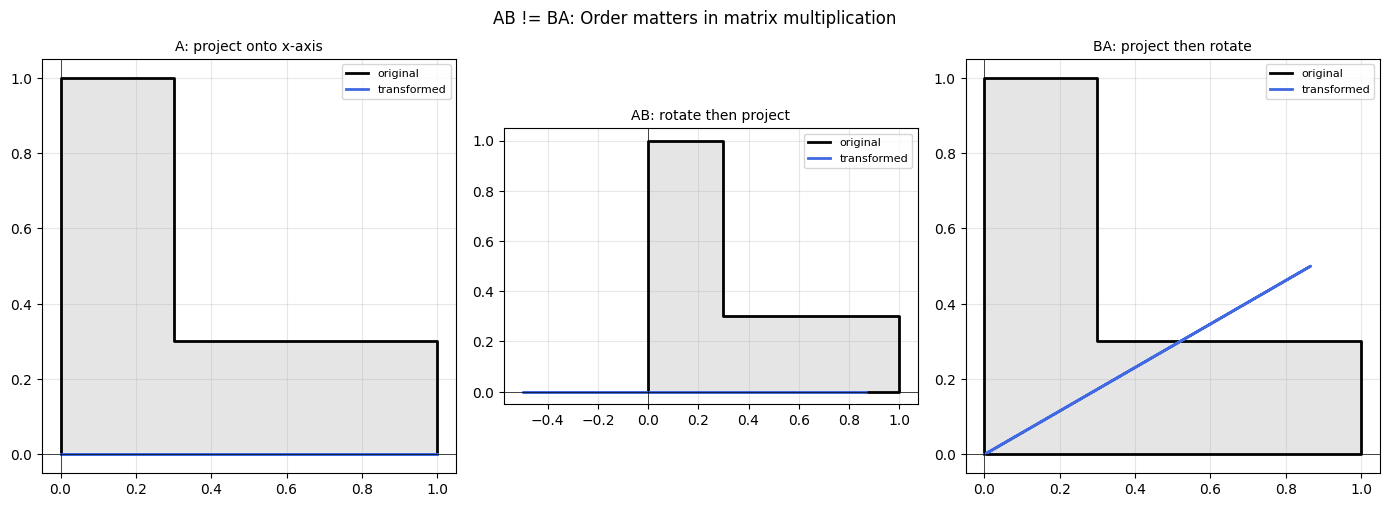

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Projection A and Rotation B
A_proj = np.array([[1,0],[0,0]])  # projection onto x-axis
theta = np.pi/6
B_rot  = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])  # 30 deg rotation

AB = A_proj @ B_rot
BA = B_rot @ A_proj

print('=== Non-Commutativity: Projection A and Rotation B ===')
print(f'A (projection):\n{A_proj}')
print(f'B (rotation 30 deg):\n{B_rot.round(4)}')
print(f'AB (rotate then project):\n{AB.round(4)}')
print(f'BA (project then rotate):\n{BA.round(4)}')
print(f'AB == BA? {np.allclose(AB, BA)}')

# Geometric demonstration
fig, axes = plt.subplots(1,3,figsize=(14,5))
def draw_transform(ax, mat, title):
    # Draw L-shape before and after
    pts = np.array([[0,0],[1,0],[1,0.3],[0.3,0.3],[0.3,1],[0,1],[0,0]]).T
    xf = mat @ pts
    ax.plot(pts[0],pts[1],'k-',lw=2,label='original')
    ax.fill(pts[0,:-1],pts[1,:-1],'gray',alpha=0.2)
    ax.plot(xf[0],xf[1],'royalblue',lw=2,label='transformed')
    ax.fill(xf[0,:-1],xf[1,:-1],'royalblue',alpha=0.3)
    ax.axhline(0, color='k',lw=0.5); ax.axvline(0, color='k',lw=0.5)
    ax.set_aspect('equal'); ax.grid(True,alpha=0.3); ax.legend(fontsize=8)
    ax.set_title(title,fontsize=10)
draw_transform(axes[0], A_proj, 'A: project onto x-axis')
draw_transform(axes[1], AB, 'AB: rotate then project')
draw_transform(axes[2], BA, 'BA: project then rotate')
plt.suptitle('AB != BA: Order matters in matrix multiplication', fontsize=12)
plt.tight_layout(); plt.show()

---
### 5-6. Column and Row Selection

Right-multiplying $A$ by $e^{(j)}$ selects the $j$-th column:
$$Ae^{(j)} = j\text{-th column of }A$$

Left-multiplying $A$ by $(e^{(i)})^T$ selects the $i$-th row:
$$(e^{(i)})^T A = i\text{-th row of }A$$

### 7-8. Permutation Matrices

A permutation matrix $P$ has distinct standard unit vectors as **columns**.  
Right-multiplying $A$ by $P$ **permutes the columns** of $A$.  
Left-multiplying $A$ by $P$ **permutes the rows** of $A$.

**Example:**
$$\begin{bmatrix}\alpha&\beta&\gamma&\delta\\\kappa&\lambda&\mu&\nu\\\phi&\chi&\psi&\omega\end{bmatrix}
\begin{bmatrix}0&0&1&0\\0&0&0&1\\1&0&0&0\\0&1&0&0\end{bmatrix} = 
\begin{bmatrix}\gamma&\delta&\alpha&\beta\\\mu&\nu&\kappa&\lambda\\\psi&\omega&\phi&\chi\end{bmatrix}$$


In [3]:
# Column and row selection
A = np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12]], dtype=float)
print('A ='); print(A)

# Select column 2 (0-indexed: column 1)
j = 1
e_j = np.zeros(4); e_j[j] = 1
col_j = A @ e_j
print(f'\nA @ e^({j+1}) = {col_j}  (column {j+1} of A: {A[:,j]})')

# Select row 1 (0-indexed: row 0)
i = 0
e_i = np.zeros(3); e_i[i] = 1
row_i = e_i @ A
print(f'(e^({i+1}))^T @ A = {row_i}  (row {i+1} of A: {A[i,:]})')

# Permutation matrix (column permutation)
P = np.array([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]], dtype=float)
AP = A @ P
print(f'\nPermutation P (columns 3,4,1,2):\n{P.astype(int)}')
print(f'AP = A @ P (permutes columns):\n{AP}')

# Row permutation
Q = np.array([[0,0,1],[1,0,0],[0,1,0]], dtype=float)
QA = Q @ A
print(f'\nQ (row permutation: rows 3,1,2):\n{Q.astype(int)}')
print(f'QA = Q @ A (permutes rows):\n{QA}')

A =
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]

A @ e^(2) = [ 2.  6. 10.]  (column 2 of A: [ 2.  6. 10.])
(e^(1))^T @ A = [1. 2. 3. 4.]  (row 1 of A: [1. 2. 3. 4.])

Permutation P (columns 3,4,1,2):
[[0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]]
AP = A @ P (permutes columns):
[[ 3.  4.  1.  2.]
 [ 7.  8.  5.  6.]
 [11. 12.  9. 10.]]

Q (row permutation: rows 3,1,2):
[[0 0 1]
 [1 0 0]
 [0 1 0]]
QA = Q @ A (permutes rows):
[[ 9. 10. 11. 12.]
 [ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]]


---
### 9-11. Matrix Transpose

The transpose $A^T$ swaps rows and columns: $(A^T)_{ij} = a_{ji}$.

$A$ is **symmetric** if $A = A^T$.

**Key identity:** $(AB)^T = B^T A^T$

*Proof:* The $(i,j)$-th entry of $(AB)^T$ equals the $(j,i)$-th entry of $AB$, which is the dot product of row $j$ of $A$ with column $i$ of $B$. This equals the dot product of column $j$ of $A^T$ with row $i$ of $B^T$, which is the $(i,j)$-th entry of $B^T A^T$. $\square$

### 13-14. Inverse of a Permutation Matrix

For any permutation matrix $P$: $P^T P = I$ (since dot product of two different columns is 0, same column is 1).  
Therefore: $P^{-1} = P^T$.


In [4]:
# Transpose examples
row_vec = np.array([[1,2,3]])
print(f'Row vector: {row_vec}')
print(f'Transpose: {row_vec.T}')

M = np.array([[5,1],[2,4],[6,7]])
print(f'\nM =\n{M}')
print(f'M^T =\n{M.T}')

S = np.array([[1,2,3],[2,4,5],[3,5,6]])
print(f'\nSymmetric matrix S =\n{S}')
print(f'S == S^T: {np.all(S == S.T)}')

# Verify (AB)^T = B^T A^T
A_t = np.array([[1,2],[3,4],[5,6]])
B_t = np.array([[1,0,2],[0,1,3]])
AB_t = A_t @ B_t
lhs = AB_t.T
rhs = B_t.T @ A_t.T
print(f'\nVerify (AB)^T = B^T A^T:')
print(f'(AB)^T =\n{lhs}')
print(f'B^T A^T =\n{rhs}')
print(f'Equal? {np.allclose(lhs, rhs)}')

# Verify P^T P = I for permutation matrix
P = np.array([[0,0,1],[1,0,0],[0,1,0]], dtype=float)
print(f'\nP^T P =\n{(P.T @ P).astype(int)}  (should be I)')

Row vector: [[1 2 3]]
Transpose: [[1]
 [2]
 [3]]

M =
[[5 1]
 [2 4]
 [6 7]]
M^T =
[[5 2 6]
 [1 4 7]]

Symmetric matrix S =
[[1 2 3]
 [2 4 5]
 [3 5 6]]
S == S^T: True

Verify (AB)^T = B^T A^T:
(AB)^T =
[[ 1  3  5]
 [ 2  4  6]
 [ 8 18 28]]
B^T A^T =
[[ 1  3  5]
 [ 2  4  6]
 [ 8 18 28]]
Equal? True

P^T P =
[[1 0 0]
 [0 1 0]
 [0 0 1]]  (should be I)


---
## Summary

| Concept | Formula |
|---|---|
| Cascade | $y=(AB)x=A(Bx)$ |
| Associativity | $(AB)C=A(BC)$ |
| Non-commutativity | $AB\neq BA$ in general |
| Column selection | $Ae^{(j)}=$ col $j$ |
| Row selection | $(e^{(i)})^TA=$ row $i$ |
| Transpose identity | $(AB)^T=B^TA^T$ |
| Permutation inverse | $P^{-1}=P^T$ |

### Mistakes to Avoid
1. Assuming $AB = BA$ — always check if order matters.
2. In $(AB)^T = B^TA^T$: the **order reverses**. A common error is writing $A^TB^T$.
3. Forgetting that right-multiplying by $P$ permutes **columns**, left-multiplying permutes **rows**.
